## Dataset

In [1]:
corpus = [
    "cat eats fish",
    "dog eats meat",
    "cat likes milk",
    "dog likes bone"
]

print(corpus)

['cat eats fish', 'dog eats meat', 'cat likes milk', 'dog likes bone']


## One-Hot Encoding

In [2]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Build vocabulary
words = sorted(set(" ".join(corpus).split()))

print("Vocabulary:")
print(words)

Vocabulary:
['bone', 'cat', 'dog', 'eats', 'fish', 'likes', 'meat', 'milk']


In [3]:
# Integer encoding
word_to_int = {word:i for i,word in enumerate(words)}

print("\nWord to Integer Mapping")
print(word_to_int)


Word to Integer Mapping
{'bone': 0, 'cat': 1, 'dog': 2, 'eats': 3, 'fish': 4, 'likes': 5, 'meat': 6, 'milk': 7}


In [4]:
# One-hot vectors
one_hot = np.eye(len(words))

print("\nOne-Hot Encoding")

for word in words:
    print(word, one_hot[word_to_int[word]])


One-Hot Encoding
bone [1. 0. 0. 0. 0. 0. 0. 0.]
cat [0. 1. 0. 0. 0. 0. 0. 0.]
dog [0. 0. 1. 0. 0. 0. 0. 0.]
eats [0. 0. 0. 1. 0. 0. 0. 0.]
fish [0. 0. 0. 0. 1. 0. 0. 0.]
likes [0. 0. 0. 0. 0. 1. 0. 0.]
meat [0. 0. 0. 0. 0. 0. 1. 0.]
milk [0. 0. 0. 0. 0. 0. 0. 1.]


## Bag of Words

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(corpus)

bow = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(bow)

   bone  cat  dog  eats  fish  likes  meat  milk
0     0    1    0     1     1      0     0     0
1     0    0    1     1     0      0     1     0
2     0    1    0     0     0      1     0     1
3     1    0    1     0     0      1     0     0


## TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    np.round(X.toarray(),3),
    columns=tfidf.get_feature_names_out()
)

print(tfidf_df)

    bone    cat    dog   eats   fish  likes   meat   milk
0  0.000  0.526  0.000  0.526  0.668  0.000  0.000  0.000
1  0.000  0.000  0.526  0.526  0.000  0.000  0.668  0.000
2  0.000  0.526  0.000  0.000  0.000  0.526  0.000  0.668
3  0.668  0.000  0.526  0.000  0.000  0.526  0.000  0.000


## Word2Vec

In [7]:
from gensim.models import Word2Vec

sentences = [sentence.split() for sentence in corpus]

model = Word2Vec(
    sentences,
    vector_size=5,
    window=2,
    min_count=1,
    workers=1,
    sg=0      # CBOW
)

print("Vocabulary")
print(model.wv.index_to_key)

print("\nEmbedding of 'cat'")
print(model.wv["cat"])

print("\nEmbedding of 'dog'")
print(model.wv["dog"])

Vocabulary
['likes', 'dog', 'eats', 'cat', 'bone', 'milk', 'meat', 'fish']

Embedding of 'cat'
[-0.03632035  0.0575316   0.01983747 -0.1657043  -0.18897636]

Embedding of 'dog'
[-0.14233617  0.12917745  0.17945977 -0.10030856 -0.07526743]


In [8]:
#Similarity
print(model.wv.similarity("cat","dog"))

0.6178626


In [9]:
print(model.wv.similarity("cat","bone"))

-0.3469331


## GloVe

In [10]:
!pip install gensim
!pip install gensim requests

In [11]:
#Download glove.2024.wikigiga.100d.zip from https://github.com/stanfordnlp/GloVe and extract to get this.txt file. 
#Then keep it in the location of Jupter

from gensim.models import KeyedVectors

glove = KeyedVectors.load_word2vec_format(
    "wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt",   
    binary=False,
    no_header=True
)

In [12]:
print(glove["king"][:10])

[-0.138498 -0.44551  -0.079252  0.063923 -0.31674  -0.097429  0.20663
  0.438389  0.294288  0.034275]


In [13]:
print(glove.similarity("king", "queen"))

0.7547443


In [14]:
print(glove.most_similar("computer", topn=10))

[('computers', 0.8939070105552673), ('software', 0.8686384558677673), ('technology', 0.8011660575866699), ('hardware', 0.761071503162384), ('internet', 0.7608765363693237), ('electronic', 0.7591760754585266), ('digital', 0.7526193857192993), ('computing', 0.7463564872741699), ('systems', 0.7461952567100525), ('pc', 0.7418347001075745)]


In [15]:
print("apple" in glove)

True


In [16]:
print(glove.vector_size)

100


In [17]:
print(glove.most_similar("cat", topn=10)) #GloVe

[('dog', 0.8964831829071045), ('rabbit', 0.7533817291259766), ('dogs', 0.7484853863716125), ('pet', 0.7425076365470886), ('cats', 0.7364459037780762), ('monkey', 0.7352023720741272), ('bird', 0.724258303642273), ('puppy', 0.7097471356391907), ('mouse', 0.698798418045044), ('horse', 0.6860377192497253)]


In [18]:
print(model.wv.most_similar("cat")) #Word2Vec

[('milk', 0.7668752074241638), ('dog', 0.6178626418113708), ('meat', 0.5485532283782959), ('fish', 0.44495806097984314), ('likes', 0.1098024994134903), ('eats', -0.1959061473608017), ('bone', -0.3469330966472626)]


| Technique    | Learns Meaning? | Sparse/Dense | Uses Context?                     |
| ------------ | --------------- | ------------ | --------------------------------- |
| One-Hot      | ✗ No            | Sparse       | ✗ No                              |
| Bag of Words | ✗ No            | Sparse       | ✗ No                              |
| TF-IDF       | ✗ No            | Sparse       | ✗ No                              |
| Word2Vec     | ✓ Yes           | Dense        | ✓ Local context (sliding window)  |
| GloVe        | ✓ Yes           | Dense        | ✓ Global co-occurrence statistics |


In [19]:
words = [
    "king", "queen", "prince", "princess",
    "apple", "banana", "orange", "grape",
    "car", "bus", "train", "truck",
    "dog", "cat", "lion", "tiger"
]

In [20]:
vectors = [glove[word] for word in words]

In [22]:
#K-Means Clustering on Word Embeddings

from sklearn.cluster import KMeans
import pandas as pd

k = 4

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(vectors)

C:\Users\Admin\anaconda3\envs\ai\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\Admin\anaconda3\envs\ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
df = pd.DataFrame({
    "Word": words,
    "Cluster": labels
})

print(df.sort_values("Cluster"))

        Word  Cluster
7      grape        0
6     orange        0
5     banana        0
4      apple        0
11     truck        1
10     train        1
9        bus        1
8        car        1
0       king        2
1      queen        2
2     prince        2
3   princess        2
12       dog        3
13       cat        3
14      lion        3
15     tiger        3


In [26]:
!pip install matplotlib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

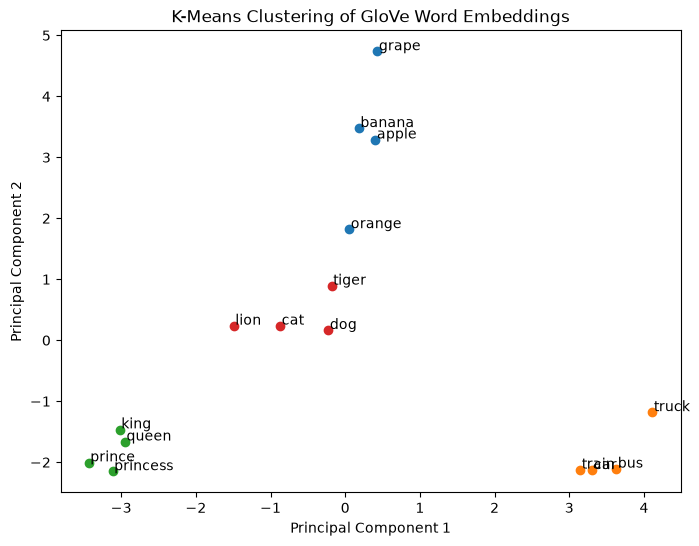

In [27]:
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(reduced[i,0], reduced[i,1], c=f"C{labels[i]}")
    plt.text(reduced[i,0]+0.02, reduced[i,1]+0.02, word)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of GloVe Word Embeddings")
plt.show()